In [ ]:
# shell
# python -m venv .venv       

# In cmd.exe
# .venv\Scripts\activate.bat

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import importlib
from tqdm.notebook import tqdm


import torch
import torch.nn.functional as F
from torch import nn
from torch import Tensor
from einops import rearrange, repeat
from einops.layers.torch import Rearrange

In [12]:
import umap 

In [2]:
import myVAE
importlib.reload(myVAE)

from myVAE import VAE

In [48]:
# https://www.kaggle.com/datasets/infamouscoder/dataset-netflix-shows
# https://www.kaggle.com/code/samad0015/eda-on-netflix-shows
path = "../data/netflix_titles.csv"
df = pd.read_csv(path)

n, d = df.shape
n, d

(8807, 12)

In [18]:
df.head(3)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...


In [19]:
df.describe(include='all')

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
count,8807,8807,8807,6173,7982,7976,8797,8807.000000,8803,8804,8807,8807
unique,8807,2,8807,4528,7692,748,1767,NaN,17,220,514,8775
top,s8807,Movie,Zubaan,Rajiv Chilaka,David Attenborough,United States,"January 1, 2020",NaN,TV-MA,1 Season,"Dramas, International Movies","Paranormal activity at a lush, abandoned prope..."
freq,1,6131,1,19,19,2818,109,NaN,3207,1793,362,4
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2014.180198,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8.819312,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1925.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2013.000000,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.000000,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2019.000000,NaN,NaN,NaN,NaN


<br>
<br>

Model

In [14]:
from sentence_transformers import SentenceTransformer

In [116]:
model = SentenceTransformer('all-MiniLM-L6-v2')
d_emb = model.encode('text').shape

country

In [ ]:
encoded_country = model.encode(df['country'].fillna("Unknown"), normalize_embeddings=True)

In [55]:
encoded_listed = model.encode(df['listed_in'].fillna("Unknown"), normalize_embeddings=True)

In [57]:
UMAP = umap.UMAP()

In [ ]:
reduction = UMAP.fit_transform(encoded_listed)

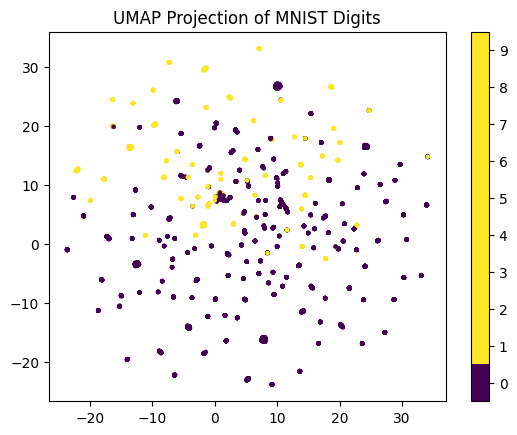

In [62]:
labels = np.zeros(n)
for i, line in enumerate(df['listed_in'].fillna("Unknown")):
    if 'Comedies' in line:
        labels[i] = 1


# Plot the result
plt.scatter(reduction[:, 0], reduction[:, 1], c=labels, s=5)
plt.colorbar(boundaries=np.arange(11)-0.5).set_ticks(np.arange(10))
plt.title('UMAP Projection of MNIST Digits')
plt.show()

In [113]:
_, d_emb = encoded_country.shape

In [81]:
def CosineSimilarity(z, X, sort_idx = False):
    norm = (np.linalg.norm(z) * np.linalg.norm(X, axis=1, keepdims=True))
    cosine_similarity = ((X @ z.T) / norm).squeeze()
    
    idx = np.argsort(-cosine_similarity.squeeze()) if sort_idx else None

    return cosine_similarity, idx

In [75]:
X = encoded_listed
z = model.encode(['Comedies'],  normalize_embeddings=True)

In [ ]:
cosine_similarity, idx = CosineSimilarity(z, X, True)

for i in idx:
    print(f"{i} \t distance: {cosine_similarity[i]: .4f} \t list_in: {df['listed_in'][i]}") 

5487 	 distance:  1.0000 	 list_in: Comedies
27 	 distance:  1.0000 	 list_in: Comedies
3583 	 distance:  1.0000 	 list_in: Comedies
562 	 distance:  1.0000 	 list_in: Comedies
2172 	 distance:  1.0000 	 list_in: Comedies
1617 	 distance:  1.0000 	 list_in: Comedies
2677 	 distance:  1.0000 	 list_in: Comedies
8420 	 distance:  1.0000 	 list_in: Comedies
2680 	 distance:  1.0000 	 list_in: Comedies
6779 	 distance:  1.0000 	 list_in: Comedies
5993 	 distance:  1.0000 	 list_in: Comedies
5493 	 distance:  1.0000 	 list_in: Comedies
8433 	 distance:  1.0000 	 list_in: Comedies
6000 	 distance:  1.0000 	 list_in: Comedies
584 	 distance:  1.0000 	 list_in: Comedies
4912 	 distance:  1.0000 	 list_in: Comedies
3629 	 distance:  1.0000 	 list_in: Comedies
5755 	 distance:  1.0000 	 list_in: Comedies
3827 	 distance:  1.0000 	 list_in: Comedies
6425 	 distance:  1.0000 	 list_in: Comedies
5328 	 distance:  1.0000 	 list_in: Comedies
152 	 distance:  1.0000 	 list_in: Comedies
6583 	 distance

<br>

In [137]:
genre = ['Sci-Fi']
state = ['United States']
year = 2020




z_genre = model.encode(genre,  normalize_embeddings=True)
z_state = model.encode(state,  normalize_embeddings=True)

In [138]:
score_genre, _ = CosineSimilarity(z_genre, encoded_listed)
score_state, _ = CosineSimilarity(z_state, encoded_country)

score_year  =  1/(np.sqrt((df['release_year'].to_numpy() - year) **2) + 1)
score_year

array([1.        , 0.5       , 0.5       , ..., 0.08333333, 0.06666667,
       0.16666667])

In [141]:
score = (score_genre + score_state + score_year)/3
idx = np.argsort(-score)

In [143]:
for i in idx:
    print(f"{i} \t distance: {score[i]: .4f} \t genre: {df['title'][i]}, \t state: {df['country'][i]} ") 

0 	 distance:  0.8461 	 genre: Dick Johnson Is Dead, 	 state: United States 
2559 	 distance:  0.8461 	 genre: Becoming, 	 state: United States 
2248 	 distance:  0.8461 	 genre: The Claudia Kishi Club, 	 state: United States 
2779 	 distance:  0.8461 	 genre: Crip Camp: A Disability Revolution, 	 state: United States 
2199 	 distance:  0.8461 	 genre: The Speed Cubers, 	 state: United States 
2547 	 distance:  0.8461 	 genre: Have a Good Trip: Adventures in Psychedelics, 	 state: United States 
1558 	 distance:  0.8461 	 genre: Giving Voice, 	 state: United States 
2095 	 distance:  0.8461 	 genre: Making The Witcher, 	 state: United States 
1962 	 distance:  0.8461 	 genre: A Love Song for Latasha, 	 state: United States 
1960 	 distance:  0.8461 	 genre: Kiss the Ground, 	 state: United States 
1926 	 distance:  0.8461 	 genre: American Murder: The Family Next Door, 	 state: United States 
2035 	 distance:  0.8461 	 genre: The Social Dilemma, 	 state: United States 
1204 	 distance: